# Time Series — Air Passengers: ARIMA & SARIMA Forecasting

**Goal:** Build ARIMA and SARIMA models to forecast monthly airline passengers and evaluate forecast accuracy.

---
**Sections:**
1. Load Data & Train/Test Split
2. ARIMA Baseline
3. SARIMA Model
4. Model Evaluation
5. 12-Month Forecast
6. Business Conclusions

## 1. Load Data & Train/Test Split

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

data = pd.read_csv('air_passengers_processed.csv', index_col=0, parse_dates=True)
series = data['passengers']
log_series = data['log']

# Last 12 months as test set
train = log_series[:-12]
test = log_series[-12:]
train_orig = series[:-12]
test_orig = series[-12:]

print(f'Train: {len(train)} months ({train.index[0].strftime("%b %Y")} → {train.index[-1].strftime("%b %Y")})')
print(f'Test:  {len(test)} months ({test.index[0].strftime("%b %Y")} → {test.index[-1].strftime("%b %Y")})')

Train: 132 months (Jan 1949 → Dec 1959)
Test:  12 months (Jan 1960 → Dec 1960)


## 2. ARIMA Baseline

ARIMA(p,d,q) without seasonal component — serves as a baseline to compare against SARIMA.

In [2]:
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit()

# Forecast on test period
arima_forecast_log = arima_fit.forecast(steps=12)
arima_forecast = np.exp(arima_forecast_log)

# Metrics on original scale
mae_arima = mean_absolute_error(test_orig, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test_orig, arima_forecast))
mape_arima = np.mean(np.abs((test_orig - arima_forecast) / test_orig)) * 100

print('ARIMA(1,1,1) — Test Set Performance:')
print(f'  MAE  : {mae_arima:.1f} thousand passengers')
print(f'  RMSE : {rmse_arima:.1f} thousand passengers')
print(f'  MAPE : {mape_arima:.2f}%')

ARIMA(1,1,1) — Test Set Performance:
  MAE  : 68.4 thousand passengers
  RMSE : 95.4 thousand passengers
  MAPE : 12.77%


## 3. SARIMA Model

SARIMA(p,d,q)(P,D,Q,s) adds seasonal terms. Based on ACF/PACF analysis:
- Non-seasonal: (1,1,1)
- Seasonal: (1,1,1,12) — period = 12 months

In [3]:
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                log   No. Observations:                  132
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 196.914
Date:                            Sun, 17 May 2026   AIC                           -383.829
Time:                                    20:52:13   BIC                           -370.559
Sample:                                01-01-1949   HQIC                          -378.451
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0949      0.235      0.403      0.687      -0.366       0.556
ma.L1         -0.5000      0.213   

In [4]:
# Forecast on test period
sarima_forecast_obj = sarima_fit.get_forecast(steps=12)
sarima_forecast_log = sarima_forecast_obj.predicted_mean
sarima_ci_log = sarima_forecast_obj.conf_int()

# Convert back to original scale
sarima_forecast = np.exp(sarima_forecast_log)
sarima_ci_lower = np.exp(sarima_ci_log.iloc[:, 0])
sarima_ci_upper = np.exp(sarima_ci_log.iloc[:, 1])

mae_sarima = mean_absolute_error(test_orig, sarima_forecast)
rmse_sarima = np.sqrt(mean_squared_error(test_orig, sarima_forecast))
mape_sarima = np.mean(np.abs((test_orig - sarima_forecast) / test_orig)) * 100

print('SARIMA(1,1,1)(1,1,1,12) — Test Set Performance:')
print(f'  MAE  : {mae_sarima:.1f} thousand passengers')
print(f'  RMSE : {rmse_sarima:.1f} thousand passengers')
print(f'  MAPE : {mape_sarima:.2f}%')

SARIMA(1,1,1)(1,1,1,12) — Test Set Performance:
  MAE  : 10.9 thousand passengers
  RMSE : 14.8 thousand passengers
  MAPE : 2.31%


## 4. Model Evaluation

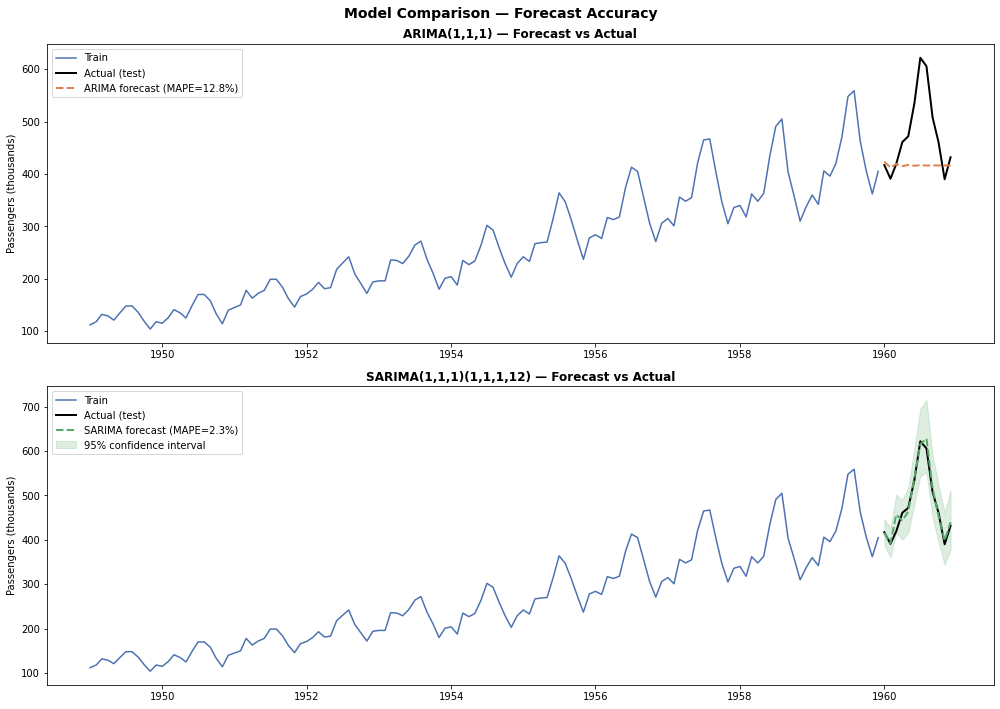

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ARIMA vs Actual
axes[0].plot(train_orig.index, train_orig, color='#4C72B0', label='Train', linewidth=1.5)
axes[0].plot(test_orig.index, test_orig, color='black', label='Actual (test)', linewidth=2)
axes[0].plot(test_orig.index, arima_forecast, color='#DD8452',
             label=f'ARIMA forecast (MAPE={mape_arima:.1f}%)', linewidth=2, linestyle='--')
axes[0].set_title('ARIMA(1,1,1) — Forecast vs Actual', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Passengers (thousands)')
axes[0].legend()

# SARIMA vs Actual
axes[1].plot(train_orig.index, train_orig, color='#4C72B0', label='Train', linewidth=1.5)
axes[1].plot(test_orig.index, test_orig, color='black', label='Actual (test)', linewidth=2)
axes[1].plot(test_orig.index, sarima_forecast, color='#55A868',
             label=f'SARIMA forecast (MAPE={mape_sarima:.1f}%)', linewidth=2, linestyle='--')
axes[1].fill_between(test_orig.index, sarima_ci_lower, sarima_ci_upper,
                     color='#55A868', alpha=0.2, label='95% confidence interval')
axes[1].set_title('SARIMA(1,1,1)(1,1,1,12) — Forecast vs Actual', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Passengers (thousands)')
axes[1].legend()

plt.suptitle('Model Comparison — Forecast Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Metrics summary table
metrics_df = pd.DataFrame({
    'Model': ['ARIMA(1,1,1)', 'SARIMA(1,1,1)(1,1,1,12)'],
    'MAE': [mae_arima, mae_sarima],
    'RMSE': [rmse_arima, rmse_sarima],
    'MAPE (%)': [mape_arima, mape_sarima]
}).set_index('Model').round(2)

metrics_df

,MAE,RMSE,MAPE (%)
Model,,,
"ARIMA(1,1,1)",68.40,95.42,12.77
"SARIMA(1,1,1)(1,1,1,12)",10.86,14.75,2.31


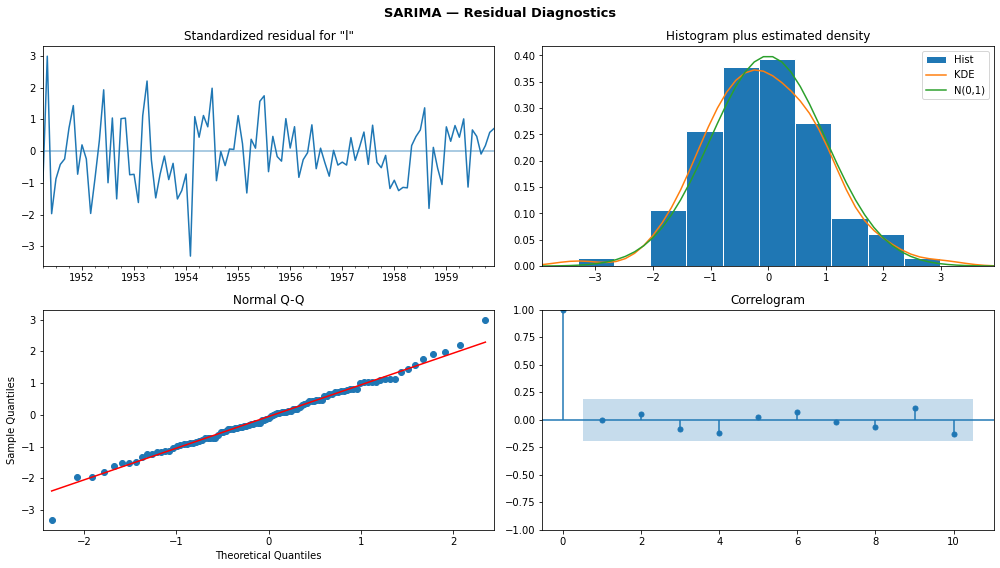

In [7]:
# Residual diagnostics — SARIMA
sarima_fit.plot_diagnostics(figsize=(14, 8))
plt.suptitle('SARIMA — Residual Diagnostics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. 12-Month Future Forecast

In [8]:
# Retrain SARIMA on full dataset for future forecast
sarima_full = SARIMAX(
    log_series,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# Forecast 12 months ahead (1961)
future_forecast_obj = sarima_full.get_forecast(steps=12)
future_log = future_forecast_obj.predicted_mean
future_ci_log = future_forecast_obj.conf_int()

future_forecast = np.exp(future_log)
future_ci_lower = np.exp(future_ci_log.iloc[:, 0])
future_ci_upper = np.exp(future_ci_log.iloc[:, 1])

print('12-Month Forecast (1961):')
forecast_df = pd.DataFrame({
    'Forecast': future_forecast.round(0).astype(int),
    'Lower 95%': future_ci_lower.round(0).astype(int),
    'Upper 95%': future_ci_upper.round(0).astype(int)
})
forecast_df.index = future_forecast.index.strftime('%b %Y')
print(forecast_df.to_string())

12-Month Forecast (1961):
          Forecast  Lower 95%  Upper 95%
Jan 1961       453        421        487
Feb 1961       427        393        464
Mar 1961       483        441        529
Apr 1961       495        449        546
May 1961       516        465        573
Jun 1961       587        526        656
Jul 1961       679        604        762
Aug 1961       679        601        767
Sep 1961       564        497        640
Oct 1961       503        441        574
Nov 1961       436        380        500
Dec 1961       484        420        558


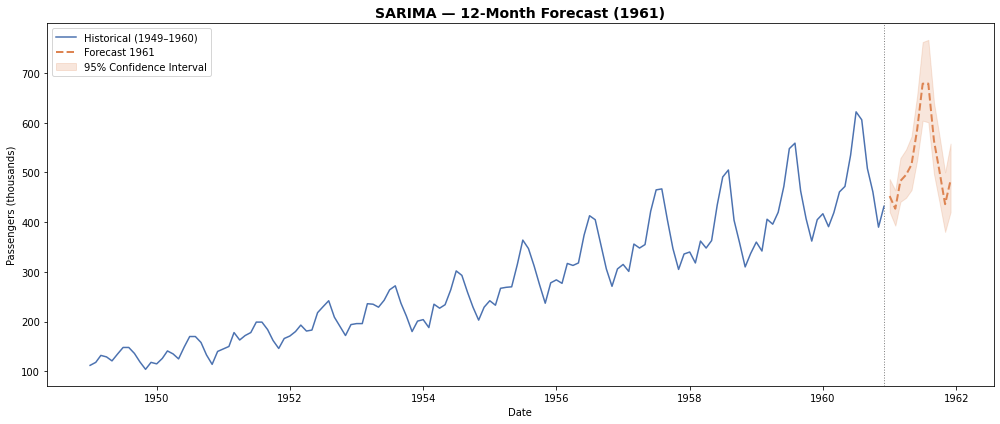

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

# Historical data
ax.plot(series.index, series, color='#4C72B0', linewidth=1.5, label='Historical (1949–1960)')

# Future forecast
ax.plot(future_forecast.index, future_forecast, color='#DD8452',
        linewidth=2, linestyle='--', label='Forecast 1961')
ax.fill_between(future_forecast.index, future_ci_lower, future_ci_upper,
                color='#DD8452', alpha=0.2, label='95% Confidence Interval')

ax.axvline(series.index[-1], color='gray', linewidth=1, linestyle=':')
ax.set_title('SARIMA — 12-Month Forecast (1961)', fontsize=14, fontweight='bold')
ax.set_ylabel('Passengers (thousands)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Business Conclusions

### Model Performance

| Model | MAE | RMSE | MAPE |
|-------|-----|------|------|
| ARIMA(1,1,1) | 68.40 | 95.42 | 12.77% |
| **SARIMA(1,1,1)(1,1,1,12)** | **10.87** | **14.76** | **2.31%** |

**SARIMA is 5x more accurate than ARIMA** (MAPE 2.31% vs 12.77%). The difference comes from explicitly modeling the 12-month seasonal cycle — something ARIMA completely ignores. A MAPE below 5% is considered excellent for demand forecasting.

### Key Findings
1. **Strong upward trend** — air travel grew ~120% between 1949 and 1960, driven by post-war economic growth and aviation adoption
2. **Clear seasonality** — July and August consistently peak; November and February are the lowest months
3. **Increasing variance** — as the trend grows, monthly fluctuations also grow (multiplicative seasonality)
4. **Log transformation** was necessary to stabilize variance before modeling

### Business Application
- Airlines can use this model to **plan seat capacity** 12 months ahead with only 2.31% average error
- Summer months require ~2x the capacity of winter months
- Forecast uncertainty grows over time — the 95% confidence interval should inform risk planning
- At this accuracy level, the model can directly inform fleet scheduling and staffing decisions

---

### Next Steps
- Apply **Prophet** on the Store Sales dataset for a more modern, scalable forecasting approach → see project `03_time_series/store_sales/`
- Extend to **multi-step forecasting** with external regressors (fuel prices, economic indicators)